# Libraries

## MICMAC Libs

In [7]:
import argparse
import os
import sys
import time
import toml
import micmac
from tqdm import trange
import lineax as lx
from IPython.utils import io
import numpyro.distributions as dist

import time
from collections import namedtuple
from functools import partial
import matplotlib.pyplot as plt

import chex as chx
import healpy as hp
import jax
import jax.numpy as jnp
import jax.random as random
import numpy as np
import numpyro
import jax.lax as jlax
from jax import config
import jax.scipy as jsp
import jaxopt
import scipy as sp
import optax
from opt_einsum import contract

from micmac.noise.noisecovar import (
    get_BtinvN,
    get_inv_BtinvNB,
    get_inv_BtinvNB_c_ell,
    get_Wd,
    get_noise_covar_extended
)
from micmac.toolbox.statistics import get_1d_recursive_empirical_covariance

from micmac.toolbox.tools import (
    get_c_ells_from_red_covariance_matrix,
    get_cell_from_map_jax,
    get_reduced_matrix_from_c_ell,
    get_reduced_matrix_from_c_ell_jax,
    get_sqrt_reduced_matrix_from_matrix_jax,
    maps_x_red_covariance_cell_JAX,
    frequency_alms_x_obj_red_covariance_cell_JAX,
    get_stacked_red_covariance_matrix_from_c_ell_jax,
    component_maps_x_redcom_covariance_cell_JAX,
    transform_alms_shape,
    alm_dot_product_JAX,
    concatenate_frequency_stokes_alm,
    concatenate_reduced_multi_components_matrix,
    alms_x_red_covariance_cell_JAX,
)

from micmac.likelihood.sampling import (
    SamplingFunctions,
    multivariate_Metropolis_Hasting_step_numpyro_bounded_dictionary_sample,
    separate_single_MH_step_index_accelerated,
    separate_single_MH_step_index_v2b,
    separate_single_MH_step_index_v4_pixel,
    separate_single_MH_step_index_v4b_pixel,
    single_Metropolis_Hasting_step,
    single_LogNormal_Metropolis_Hasting_step,
    bounded_single_Metropolis_Hasting_step,
    multivariate_Metropolis_Hasting_step_numpyro_bounded,
    multivariate_Metropolis_Hasting_step
)


config.update('jax_enable_x64', True)

sys.path.append(os.path.dirname(os.path.abspath('')))

## Additional alms CG functions

In [8]:
def frequency_almxfl_2D(alms, fl, lmax, lmin):
    assert fl.shape[0] == lmax - lmin + 1
    assert alms.shape[-1] == (lmax + 1)*(lmax//2 + 1)
    assert alms.shape[0] == fl.shape[1]
    assert alms.shape[1] == fl.shape[2]
    alms_2D = transform_alms_shape(alms, lmax = lmax, transformation = "healpix_to_2dlm")
    zero_pad = jnp.repeat(jnp.zeros_like(alms_2D[:,:,0,:])[:,:,np.newaxis,:], 2, axis = 2)
    alms_2D_result = jnp.concatenate((zero_pad, jnp.einsum("fsLm, Lfset -> etLm", alms_2D[..., lmin:, :], fl)), axis = 2)
    alms_result = transform_alms_shape(alms_2D_result, lmax = lmax, transformation = "2dlm_to_healpix")
    return alms_result

In [9]:
def component_alms_x_redcom_covariance_pixel_JAX(component_alms, redcom_pixel_covariance, nside, lmax, n_iter=3):
    """
    Return alms convolved with the pixel covariance matrix given as input
    in the format [n_pix, n_components, nstokes, n_components, nstokes], assuming it's block diagonal

    The input matrix have to start from ell=lmin, otherwise the lmax associated with the harmonic
    operations will be wrong

    Parameters
    ----------
    component_alms: array[float] of shape [n_components, nstokes, n_alms]
         input maps
    red_matrix_sqrt: array[float] of shape [n_pix, n_components, nstokes, n_components, nstokes]
        input reduced spectra
    nside: int
        nside of the input maps
    lmax: int
        maximum ell for the spectrum
    n_iter: int
        number of iterations for harmonic operations

    Returns
    -------
    maps_output: array[float] of shape [n_components, nstokes, n_alms]
        input maps convolved with input spectra
    """
    n_components = component_alms.shape[0]
    nstokes = component_alms.shape[1]

    # Wrapper for map2alm, to prepare the pure callback of JAX
    def wrapper_map2alm(maps_, lmax=lmax, n_iter=n_iter, nside=nside):
        maps_np = jax.tree.map(np.asarray, maps_).reshape((3, 12 * nside**2))
        alm_T, alm_E, alm_B = hp.map2alm(maps_np, lmax=lmax, iter=n_iter)
        return np.array([alm_T, alm_E, alm_B])
    
    # Wrapper for alm2map, to prepare the pure callback of JAX
    def wrapper_alm2map(alm_, lmax=lmax, nside=nside):
        if alm_.shape[0] != 3:
            alm_ = jnp.vstack((jnp.zeros(((3 - alm_.shape[0]), alm_.shape[1])), alm_))
        alm_np = jax.tree.map(np.asarray, alm_)
        return hp.alm2map(alm_np, nside, lmax=lmax)
    
    # Pure call back of map2alm, to be used with JAX for JIT compilation
    @partial(jax.jit, static_argnums=(1, 2))
    def pure_call_map2alm(maps_, lmax=lmax, nside=nside):
        shape_output = (3, (lmax + 1) * (lmax // 2 + 1))
        return jax.pure_callback(
            wrapper_map2alm,
            jax.ShapeDtypeStruct(shape_output, np.complex128),
            maps_.ravel(),
        )
    
    @partial(jax.jit)
    def pure_call_alm2map(alm_):
        shape_output = (3, 12 * nside**2)
        return jax.pure_callback(wrapper_alm2map, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

    if component_alms.shape[1] == 2:
        component_alms_TEB = jnp.concatenate(
            (jnp.zeros_like(component_alms[:, 0][:, None, ...]), jnp.copy(component_alms[:, ...])), axis=1
        )
    else:
        component_alms_TEB = jnp.copy(component_alms)
    component_maps_QU = jax.vmap(pure_call_alm2map)(component_alms_TEB)[
        :, 3 - nstokes :, ...
        ]
    maps_output = jnp.einsum('csp, pekcs -> ekp', component_maps_QU, redcom_pixel_covariance)

    alms_output = jax.vmap(pure_call_map2alm)(jnp.concatenate((jnp.zeros_like(maps_output[:, 0][:, None, ...]),maps_output), axis = 1))[
        :, 3 - nstokes :, ...]
    return alms_output

# Loading configs...

In [10]:
path_toml_params = "configs/icarus_test.toml"
with open(path_toml_params) as f:
    dictionary_parameters = toml.load(f)
f.close()
assert 'sampler_params' in dictionary_parameters
ICARUS_obj = micmac.create_IcarusSampler_from_dictionnary(dictionary_parameters['sampler_params'], path_file_spv='');

Loading or creating the spv config from a yaml file
No spatial variability case

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f0
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None

>>> Tree of spv config after filling the missing values:
root
  nside_spv
    default: [0]
    f0
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
      b4
        default: [0]
      b5
        default: [0]


## Generating sims

In [11]:
add_seed_rank = 42
dictionary_run_configuration = dictionary_parameters['run_configuration']
seed_realization_input = dictionary_run_configuration['seed_realization_input']
instrument = micmac.get_instrument(ICARUS_obj.instrument_name)
    # Simulate CMB, foregrounds and noise maps 

fgs_model = dictionary_run_configuration['fgs_model']
print('Simulating input maps!', flush=True) 
np.random.seed(seed_realization_input+add_seed_rank)
freq_maps_fgs_denoised = micmac.get_observation(instrument, fgs_model, nside=ICARUS_obj.nside, noise=False)[
    :, 1:, :]


freq_maps_fgs_denoised = jax.vmap(ICARUS_obj.get_band_limited_maps, in_axes = 0, out_axes = 0)(freq_maps_fgs_denoised)
    
print(f"Setting up noise with seed {seed_realization_input+add_seed_rank}!", flush=True)

def gen_noise_map(seed_realization_input, add_seed_rank, instrument):
    np.random.seed(seed_realization_input+add_seed_rank)
    noise_map = micmac.get_noise_realization(ICARUS_obj.nside, instrument)[:, 1:, :]
    return noise_map
    
new_noise_map = gen_noise_map(seed_realization_input, add_seed_rank, instrument)
freq_maps_fgs = freq_maps_fgs_denoised + new_noise_map

print('Shape for input frequency maps :', freq_maps_fgs.shape)

r_true = dictionary_run_configuration['r_true']
print(f"Setting up CMB with seed {seed_realization_input + 1 +add_seed_rank}!", flush=True)
print(f"Simulating CMB with input r = {r_true}")

def gen_input_maps(r_true, seed_realization_input, add_seed_rank, freq_maps_fgs):
    seed_realization_CMB = seed_realization_input + 1

    np.random.seed(seed_realization_CMB+add_seed_rank)
    return ICARUS_obj.generate_input_freq_maps_from_fgs(freq_maps_fgs, 
                                                        r_true=r_true,
                                                        return_only_freq_maps=False)
    
input_freq_maps, input_cmb_maps, theoretical_red_cov_r0_total, theoretical_red_cov_r1_tensor = gen_input_maps(r_true, seed_realization_input, add_seed_rank, freq_maps_fgs)
theoretical_r0_total = micmac.get_c_ells_from_red_covariance_matrix(
    theoretical_red_cov_r0_total
) 
theoretical_r1_tensor = micmac.get_c_ells_from_red_covariance_matrix(
    theoretical_red_cov_r1_tensor
) 

# input_freq_maps_masked = input_freq_maps

Simulating input maps!
['d0']
Setting up noise with seed 84!
Shape for input frequency maps : (6, 2, 12288)
Setting up CMB with seed 85!
Simulating CMB with input r = 0.001
Calculating spectra from CAMB !
Calculating spectra from CAMB !


## Masking

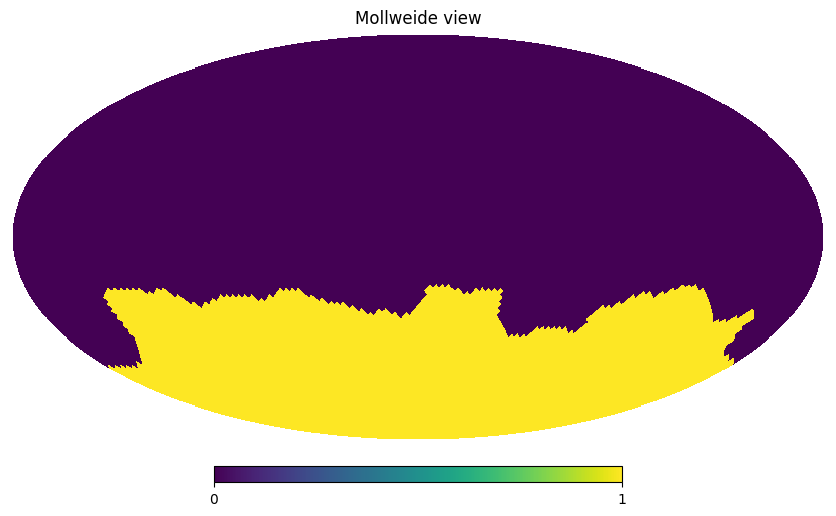

In [12]:
nside = ICARUS_obj.nside
nstokes = ICARUS_obj.nstokes
lmin = ICARUS_obj.lmin
lmax = ICARUS_obj.lmax
n_iter = 3
n_components = 1#ICARUS_obj.n_components
n_frequencies = ICARUS_obj.n_frequencies
n_correlations = ICARUS_obj.n_correlations
n_pix = hp.nside2npix(nside)
n_lms = (lmax + 1) * (lmax // 2 + 1)
foreground_maps_only = False
filedir = ""
mask_mode = "Planck" # "SO", "None"
list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_Planck_60_0_5_10_deg_no_pure.npy")
if mask_mode == "Planck":
    mask = hp.ud_grade(np.load(f"{filedir}masks/mask_60.npy"), nside_out = nside)
    list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_Planck_60_0_5_10_deg_no_pure.npy")
    phi_ang, theta_ang = hp.pix2ang(ICARUS_obj.nside, np.arange(mask.size), lonlat=True)
    mask[theta_ang>0] = 0
elif mask_mode == "SO":
    mask = hp.ud_grade(hp.read_map(f"{filedir}masks/mask_SO_SAT_apodized.fits", field = 0), nside_out = ICARUS_obj.nside)
    mask[mask > 0.3] = 1.0
    mask[mask < 0.3] = 0
    phi_ang, theta_ang = hp.pix2ang(ICARUS_obj.nside, np.arange(mask.size), lonlat=True)
    mask[theta_ang>0] = 0
    list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_SO_SAT_0_5_10_deg_no_pure.npy")
else:
    mask = np.ones(hp.nside2npix(ICARUS_obj.nside))
    list_mode_coupling_mixing_matrices_nopure = np.eye(np.shape(list_mode_coupling_mixing_matrices_nopure)[0])
f_sky = np.mean(mask)
if dictionary_parameters['sampler_params']['instrument_name'] == "SO_SAT":
    A_dust = np.load(f"{filedir}fgs_params/dust_law_SO.npy")
    A_sync = np.load(f"{filedir}fgs_params/sync_law_SO.npy")
else:
    A_dust = np.load(f"{filedir}fgs_params/dust_law.npy")
    A_sync = np.load(f"{filedir}fgs_params/sync_law.npy")
B = np.ones((n_frequencies, n_components, n_pix))
if foreground_maps_only:
    B[:,0,:] = np.repeat(A_dust[...,np.newaxis], n_pix, axis = 1)
if n_components>1:
    B[:,1,:] = np.repeat(A_dust[...,np.newaxis], n_pix, axis = 1)
if n_components>2:
    B[:,2,:] = np.repeat(A_sync[...,np.newaxis], n_pix, axis = 1)
B = B*mask
hp.mollview(mask)


In [13]:
# Wrapper for map2alm, to prepare the pure callback of JAX
n_iter = 10
def wrapper_map2alm(maps_, lmax=lmax, n_iter=n_iter, nside=nside):
    maps_np = jax.tree.map(np.asarray, maps_).reshape((3, 12 * nside**2))
    alm_T, alm_E, alm_B = hp.map2alm(maps_np, lmax=lmax, iter=n_iter)
    return np.array([alm_T, alm_E, alm_B])

# Wrapper for alm2map, to prepare the pure callback of JAX
def wrapper_alm2map(alm_, lmax=lmax, nside=nside):
    if alm_.shape[0] != 3:
        alm_ = jnp.vstack((jnp.zeros(((3 - alm_.shape[0]), alm_.shape[1])), alm_))
    alm_np = jax.tree.map(np.asarray, alm_)
    return hp.alm2map(alm_np, nside, lmax=lmax)

# Pure call back of map2alm, to be used with JAX for JIT compilation
@partial(jax.jit, static_argnums=(1, 2))
def pure_call_map2alm(maps_, lmax=lmax, nside=nside):
    shape_output = (3, (lmax + 1) * (lmax // 2 + 1))
    return jax.pure_callback(
        wrapper_map2alm,
        jax.ShapeDtypeStruct(shape_output, np.complex128),
        maps_.ravel(),
    )

@partial(jax.jit)
def pure_call_alm2map(alm_):
    shape_output = (3, 12 * nside**2)
    return jax.pure_callback(wrapper_alm2map, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

## Noise

In [14]:
noise_factor = 1
depth_p = jnp.array(instrument["depth_p"])*noise_factor
noise_maps = new_noise_map*noise_factor
invN = get_noise_covar_extended(depth_p, nside)*mask

N_ell = micmac.noisecovar.get_Cl_noise_JAX(jnp.array(depth_p), np.mean(B, axis = 2), lmax = lmax)#*f_sky**2
# plt.plot(N_ell[0,0,2:])

# if f_sky < 1.:
#     coupling_correction = (
#         list_mode_coupling_mixing_matrices_nopure[0, 0::4, 0::4]
#     )[:lmax+1, :lmax+1]

#     coupling_correction = 0.5 * (
#         coupling_correction + coupling_correction.T
#     )

#     eigvals, eigvecs = jnp.linalg.eigh(coupling_correction)

#     eps = 1e-15 * jnp.max(eigvals)
#     safe_eigvals = jnp.where(eigvals > eps, eigvals, 1.0)

#     # Rotate to eigenbasis
#     N_rot = jnp.einsum("ij,...j->...i", eigvecs.T, N_ell)

#     # Apply M * N * M^{-1} in eigenbasis
#     N_rot = eigvals * N_rot / safe_eigvals

#     # Rotate back
#     N_ell = jnp.abs(jnp.einsum("ij,...j->...i", eigvecs, N_rot))
N_c_ell = micmac.noisecovar.get_true_Cl_noise(jnp.array(depth_p), lmax = lmax)

## Preping spectra

In [15]:
d_temp_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_q_new.fits"), nside_out = ICARUS_obj.nside)
d_temp_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_u_new.fits"), nside_out = ICARUS_obj.nside)
S_dust = hp.anafast(np.vstack((jnp.ones_like(d_temp_Q),d_temp_Q, d_temp_U)*mask), lmax = ICARUS_obj.lmax)#/f_sky

s_temp_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_q_new.fits"), nside_out = ICARUS_obj.nside)
s_temp_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_u_new.fits"), nside_out = ICARUS_obj.nside)
S_sync = hp.anafast(np.vstack((jnp.ones_like(s_temp_Q),s_temp_Q, s_temp_U)*mask), lmax = ICARUS_obj.lmax)#/f_sky

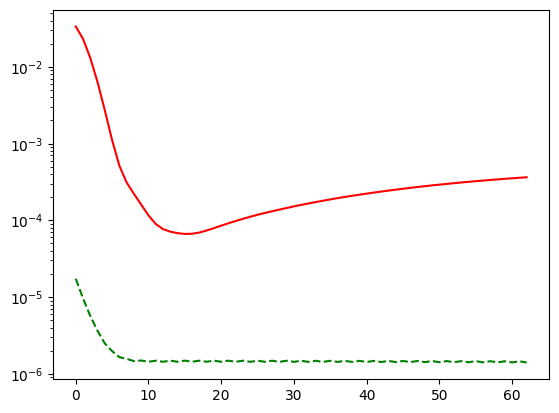

In [16]:
redcom_cov_matrix = jnp.zeros((lmax - lmin + 1,n_components, nstokes, n_components, nstokes))
if foreground_maps_only:
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,0].set(S_dust[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,1].set(S_dust[2,2:lmax+1])
    #redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,1].set(S_dust[4,2:lmax+1])
    #redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,0].set(S_dust[4,2:lmax+1])
else:
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,0].set(theoretical_red_cov_r0_total[:,0,0])
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,1].set(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true)
if n_components > 1:
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,0,1,0].set(S_dust[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,1,1,1].set(S_dust[2,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,0,1,1].set(S_dust[4,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,1,1,0].set(S_dust[4,2:lmax+1])
if n_components > 2:
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,0,2,0].set(S_sync[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,1,2,1].set(S_sync[2,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,0,2,1].set(S_sync[4,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,1,2,0].set(S_sync[4,2:lmax+1])
redcom_cov_matrix_sqrt = sp.linalg.sqrtm(redcom_cov_matrix.reshape(lmax - lmin + 1, 
                                                                         n_components*nstokes, 
                                                                         n_components*nstokes)).reshape(lmax - lmin + 1, 
                                                                                                        n_components, nstokes, 
                                                                                                        n_components, nstokes)
redcom_cov_matrix_sqrt = jnp.array(redcom_cov_matrix_sqrt)
plt.plot(theoretical_red_cov_r0_total[:,0,0]+theoretical_red_cov_r1_tensor[:,0,0]*r_true, "r-")
plt.plot(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true, "g--")
#plt.plot(S3_BB, "b--")
plt.yscale("log")

## Data building

In [17]:
if n_components > 1:
    d = (input_cmb_maps + noise_maps + freq_maps_fgs_denoised)*mask
elif foreground_maps_only:
    d = (noise_maps + freq_maps_fgs_denoised)*mask
else:
    d = (input_cmb_maps + noise_maps)*mask
d = jax.vmap(ICARUS_obj.get_band_limited_maps, in_axes = 0, out_axes = 0)(d)

# CG terms

## $\hat{N}^{-1}$

In [18]:
#invN_sqrt = sp.linalg.sqrtm(invN.transpose(2,0,1)).transpose(1,2,0)
invN_sqrt = jnp.sqrt(invN.transpose(2,0,1)).transpose(1,2,0)
invBtinvNB = micmac.noisecovar.get_inv_BtinvNB(invN, B)
BtinvN_sqrt = get_BtinvN(invN_sqrt, B)
#mask = jnp.ones(hp.nside2npix(nside))
redcom_N = jnp.einsum('cdp,sk->pcsdk',invBtinvNB, np.eye(nstokes))
#redcom_N = jnp.einsum('cdp,sk->pcsdk',invBtinvNB, np.eye(nstokes))
print(redcom_N.shape)
redcom_N_inv = jnp.copy(redcom_N)
redcom_N_inv = redcom_N_inv.at[mask != 0].set(jnp.linalg.pinv(redcom_N.reshape(n_pix, n_components*nstokes, n_components*nstokes)).reshape(n_pix, n_components, nstokes, n_components, nstokes)[mask!=0])

(12288, 1, 2, 1, 2)


## RHS Wiener Filter: $S^{1/2} \hat{N}^{-1} s_{ML}$

In [19]:
s_ML = jnp.einsum('cg...,hg...,hf...,f...->c...', invBtinvNB, B, invN, d)
invNsML = jnp.einsum('csp, pekcs -> ekp', s_ML, redcom_N_inv)
right_member_WF = component_maps_x_redcom_covariance_cell_JAX(
    invNsML/hp.nside2resol(nside)**2, redcom_cov_matrix_sqrt, nside=nside, lmin=lmin, n_iter=n_iter
)
right_member_WF_alms = jax.vmap(pure_call_map2alm)(np.concatenate((jnp.zeros_like(right_member_WF[:, 0][:, None, ...]),right_member_WF), axis = 1))[
    :, 3 - nstokes :, ...]

## RHS Fluctuations: $\xi + S^{1/2} B^T N^{-1/2} \chi$

In [20]:
jax_key_PNRG = random.PRNGKey(42)

map_random_realization_xi=None 
map_random_realization_chi=None 
initial_guess=jnp.empty(0) 

jax_key_PNRG, jax_key_PNRG_xi = random.split(jax_key_PNRG)  # Splitting of the random key to generate a new one

# Creation of the random maps if they are not given
if map_random_realization_xi is None:
    # If no random maps are provided, then it is computed within the routine
    print('Recalculating xi !')
    map_random_realization_xi = jax.random.normal(
        jax_key_PNRG_xi, shape=(n_components, nstokes, n_pix)
    ) / hp.nside2resol(nside)

jax_key_PNRG, *jax_key_PNRG_chi = random.split(
    jax_key_PNRG, n_frequencies + 1
)  # Splitting of the random key to generate a new one
if map_random_realization_chi is None:
    # If no random maps are provided, then it is computed within the routine
    print('Recalculating chi !')

    def fmap(random_key):
        random_map = jax.random.normal(random_key, shape=(nstokes, n_pix))
        # return get_band_limited_maps(random_map)
        return random_map

    map_random_realization_chi = jax.vmap(fmap)(
        jnp.array(jax_key_PNRG_chi)
    ) / hp.nside2resol(nside) # Generating a different random Gaussian map for each frequency

    chx.assert_shape(map_random_realization_chi, (n_frequencies, nstokes, n_pix))

# Computation of the right side member of the CG

# First right member: xi
right_member_1 = map_random_realization_xi
# Second right member:

## Computation of \chi term = S^{1/2} B^t N^{-1/2} \chi
# First compute B^t N^{-1/2} \chi
right_member_2_part = jnp.einsum('cfp,fsp->csp', BtinvN_sqrt/hp.nside2resol(nside), map_random_realization_chi)

# Then apply S^{1/2} to B^t N^{-1/2} \chi
right_member_2 = component_maps_x_redcom_covariance_cell_JAX(
    right_member_2_part, redcom_cov_matrix_sqrt, nside=nside, lmin=lmin, n_iter=n_iter
)

right_member_fluct = (jax.vmap(ICARUS_obj.get_band_limited_maps)(right_member_1)) + right_member_2

right_member_fluct_alms = jax.vmap(pure_call_map2alm)(np.concatenate((jnp.zeros_like(right_member_fluct[:, 0][:, None, ...]),right_member_fluct), axis = 1))[
    :, 3 - nstokes :, ...]

Recalculating xi !
Recalculating chi !


## LHS: $(I + S^{1/2} \hat{N}^{-1} S^{1/2})$

In [21]:
## Second left member pixel operator: (E^t (B^t N^{-1} B)^{-1} E) x
first_part_term_left_alms = lambda x: frequency_almxfl_2D(
    x.reshape((n_components, nstokes, n_lms)),
    redcom_cov_matrix_sqrt,
    lmax = lmax,
    lmin = lmin,
).ravel()

def second_part_term_left_alms(x):
    return component_alms_x_redcom_covariance_pixel_JAX(
        x.reshape((n_components, nstokes, n_lms)), 
        redcom_N_inv/hp.nside2resol(nside)**2,
        nside = nside,
        lmax = lmax,
    ).ravel()

func_left_term_alms = lambda x: x + first_part_term_left_alms(second_part_term_left_alms(first_part_term_left_alms(x)))

## Precond: $(I + S^{1/2} \hat{N}^{-1} S^{1/2})$

In [22]:
redcom_N_ell = jnp.einsum('cdl,sk->lcsdk',N_ell[...,lmin::], np.eye(nstokes))
inv_redcom_N_ell = jnp.linalg.pinv(redcom_N_ell.reshape(lmax - lmin + 1, 
                                                     n_components*nstokes, 
                                                     n_components*nstokes)).reshape(lmax - lmin + 1, 
                                                                                    n_components, nstokes, 
                                                                                    n_components, nstokes)

redcom_preconditioner_s = jnp.linalg.pinv(
    jnp.eye(n_components*nstokes)
    + jnp.einsum('labcd,lcdef,lefgh->labgh', redcom_cov_matrix_sqrt, inv_redcom_N_ell, redcom_cov_matrix_sqrt).reshape(lmax - lmin + 1, 
                                                     n_components*nstokes, 
                                                     n_components*nstokes),
).reshape(lmax - lmin + 1, 
            n_components, nstokes, 
            n_components, nstokes)
precond_func_alms = lambda x: frequency_almxfl_2D(
    x.reshape((n_components, nstokes, n_lms)),
    redcom_preconditioner_s,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
).ravel()

# Lineax CG solver

## Config

In [23]:
# Initial guess for the CG
initial_guess = jnp.zeros_like(right_member_WF_alms)
max_iter_CG = 10000 #400
limit_iter_cg = 10000
tolerance_CG = 1e-6
options = dict()
options['y0'] = jnp.zeros_like(initial_guess.ravel())
options['preconditioner'] = lx.FunctionLinearOperator(precond_func_alms, input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_lms,),jnp.complex128), tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))
func_lineax = lx.FunctionLinearOperator(func_left_term_alms, input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_lms,),jnp.complex128), tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))

solver = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm,)
throw = False

## Solve for WF term

In [24]:
t = time.time()
solution = lx.linear_solve(func_lineax, right_member_WF_alms.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_lms))

s_WF_alms_z = frequency_almxfl_2D(
    result_lineax,
    redcom_cov_matrix_sqrt,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
)
s_WF_alms = s_WF_alms_z.reshape((n_components, nstokes, n_lms))
print(time.time() - t)

solved in 10000 steps
38.09254026412964


## Solve for fluctuation term

In [25]:
t = time.time()
solution = lx.linear_solve(func_lineax, right_member_fluct_alms.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_lms))

fluct_alms_z = frequency_almxfl_2D(
    result_lineax,
    redcom_cov_matrix_sqrt,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
)
fluct_alms = fluct_alms_z.reshape((n_components, nstokes, n_lms))
print(time.time() - t)

solved in 10000 steps
42.536837577819824


## Solve for combined

In [26]:
t = time.time()
solution = lx.linear_solve(func_lineax, right_member_WF_alms.ravel() + right_member_fluct_alms.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_lms))

combined_alms_z = frequency_almxfl_2D(
    result_lineax,
    redcom_cov_matrix_sqrt,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
)
combined_alms = combined_alms_z.reshape((n_components, nstokes, n_lms))
print(time.time() - t)

solved in 10000 steps
46.85383653640747


# Results

## Map space

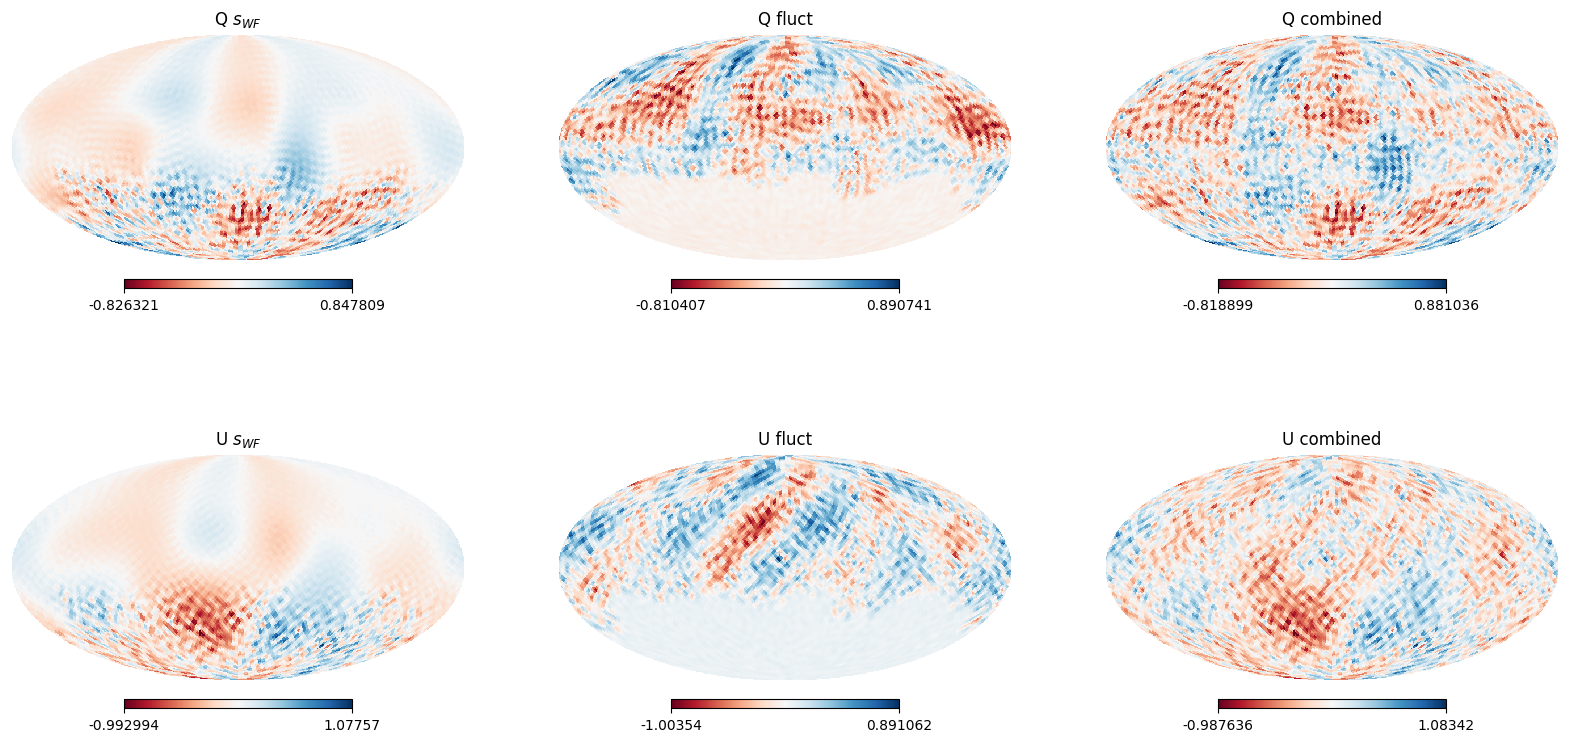

In [27]:
s_WF_maps = pure_call_alm2map(s_WF_alms[0])[1:]
fluct_maps = pure_call_alm2map(fluct_alms[0])[1:]
combined_maps = pure_call_alm2map(combined_alms[0])[1:]

fig, ax = plt.subplots(2,3, figsize = (20,10))
axf = ax.flatten()
j = 0
title_QU = ["Q", "U"]
for i in range(2):
    plt.axes(axf[j])
    hp.mollview(s_WF_maps[i], cmap = "RdBu", title = f"{title_QU[i]} $s_{{WF}}$", hold = True)
    j+=1
    plt.axes(axf[j])
    hp.mollview(fluct_maps[i], cmap = "RdBu", title = f"{title_QU[i]} fluct",  hold = True)
    j+=1
    plt.axes(axf[j])
    hp.mollview(combined_maps[i], cmap = "RdBu", title = f"{title_QU[i]} combined", hold = True)
    j+=1

## Spectra

In [28]:
s_WF_cls = hp.alm2cl(np.vstack((np.zeros_like(s_WF_alms[0,0,:]),s_WF_alms[0])))[1:3, lmin:]
fluct_cls = hp.alm2cl(np.vstack((np.zeros_like(fluct_alms[0,0,:]),fluct_alms[0])))[1:3, lmin:]
combined_cls = hp.alm2cl(np.vstack((np.zeros_like(combined_alms[0,0,:]),combined_alms[0])))[1:3, lmin:]

Text(0.5, 1.0, 'BB')

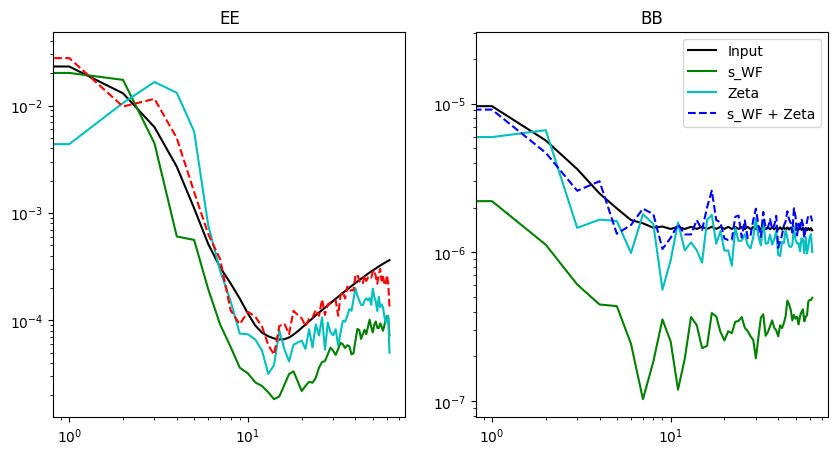

In [29]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].plot(theoretical_red_cov_r0_total[:,0,0], "k")
ax[0].plot(s_WF_cls[0], "g")
ax[0].plot(fluct_cls[0], "c")
ax[0].plot(combined_cls[0], "r--")

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].set_title("EE")

ax[1].plot(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true, "k", label = "Input")
ax[1].plot(s_WF_cls[1], "g", label = "s_WF")
ax[1].plot(fluct_cls[1], "c", label = "Zeta")
ax[1].plot(combined_cls[1], "b--", label = "s_WF + Zeta")

ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_title("BB")